# Paper Results

Run from the repo root. Generates all paper figures and Table 1 inline.

In [2]:
import sys, os, argparse, warnings
from pathlib import Path
from IPython.display import Image, display

warnings.filterwarnings("ignore")

# Ensure cwd is repo root regardless of where Jupyter was launched
_cwd = Path.cwd()
if not (_cwd / "data").exists() and (_cwd.parent / "data").exists():
    os.chdir(_cwd.parent)

assert Path("data/results").exists(), "Could not locate repo root"

sys.path.insert(0, "analysis")
sys.path.insert(0, "analysis/figs")

Path("_nb").mkdir(exist_ok=True)

import fig_2, fig_3, fig_4
from figures import load_participant_agg, icc_a1

# Default args (avoids argparse reading sys.argv)
args = argparse.Namespace(
    csv          = Path("data/results/gemini_zero_shot.csv"),
    qwen_csv     = Path("data/results/qwen_zero_shot.csv"),
    fews_csv     = Path("data/results/gemini_few_shot.csv"),
    cot_csv      = Path("data/results/gemini_cot.csv"),
    qwen_cot_csv = Path("data/results/qwen_cot.csv"),
    qwen_fews_csv= Path("data/results/qwen_few_shot.csv"),
)
print(f"Working directory: {Path.cwd()}")
print("Setup complete.")

Working directory: /Users/prabalshrestha/Documents/BSU/MIND/mllm-video-participant-eval
Setup complete.


## Table 1 — PMSV Agreement by Subgroup (zero-shot)

In [3]:
import pandas as pd
import numpy as np

gem  = load_participant_agg(Path('data/results/gemini_zero_shot.csv'))
qwen = load_participant_agg(Path('data/results/qwen_zero_shot.csv'))

def icc(df):
    d = df.dropna(subset=['human_msv', 'ai_msv'])
    return round(icc_a1(d['human_msv'].to_numpy(), d['ai_msv'].to_numpy()), 2)

rows = []
for cat, label, mask_fn in [
    ('Gender',    'Male',          lambda d: d['gender'] == 'Male'),
    ('Gender',    'Female',        lambda d: d['gender'] == 'Female'),
    ('Ethnicity', 'White',         lambda d: d['race'] == 'White or Caucasian'),
    ('Ethnicity', 'Black',         lambda d: d['race'] == 'Black'),
    ('Ethnicity', 'Asian',         lambda d: d['race'] == 'Asian'),
    ('Age',       '<39',           lambda d: d['age_group'] == 'Under 39'),
    ('Age',       '≥39',           lambda d: d['age_group'] == '39 or older'),
    ('Education', '<Bachelor\'s', lambda d: d['edu_label'] == "Below Bachelor's"),
    ('Education', '≥Bachelor\'s', lambda d: d['edu_label'] == "Bachelor's or higher"),
    ('Income',    '<$50k',         lambda d: d['income_label'] == 'Less than $50,000'),
    ('Income',    '$50–100k',      lambda d: d['income_label'] == '$50,000 \u2013 $99,999'),
    ('Income',    '≥$100k',        lambda d: d['income_label'] == '$100,000 or more'),
    ('SS',        '<2.5',          lambda d: d['sen_seek'] < 2.5),
    ('SS',        '≥2.5',          lambda d: d['sen_seek'] >= 2.5),
]:
    mg = mask_fn(gem)
    rows.append({
        'Category': cat,
        'Subgroup': label,
        'n': int(mg.sum()),
        'Gemini ICC': icc(gem[mg]),
        'Qwen ICC':   icc(qwen[mask_fn(qwen)]),
    })

df_tab = pd.DataFrame(rows)
df_tab.style.hide(axis='index')

Category,Subgroup,n,Gemini ICC,Qwen ICC
Gender,Male,318,0.220000,0.140000
Gender,Female,337,0.070000,0.140000
Ethnicity,White,466,0.130000,0.140000
Ethnicity,Black,88,0.080000,0.200000
Ethnicity,Asian,43,0.170000,0.250000
Age,<39,338,0.240000,0.140000
Age,≥39,335,0.050000,0.120000
Education,<Bachelor's,325,0.170000,0.130000
Education,≥Bachelor's,346,0.120000,0.150000
Income,<$50k,253,0.150000,0.110000


## Figure 2 — Agreement across prompting methods

[fig2] → _nb/fig_2.png


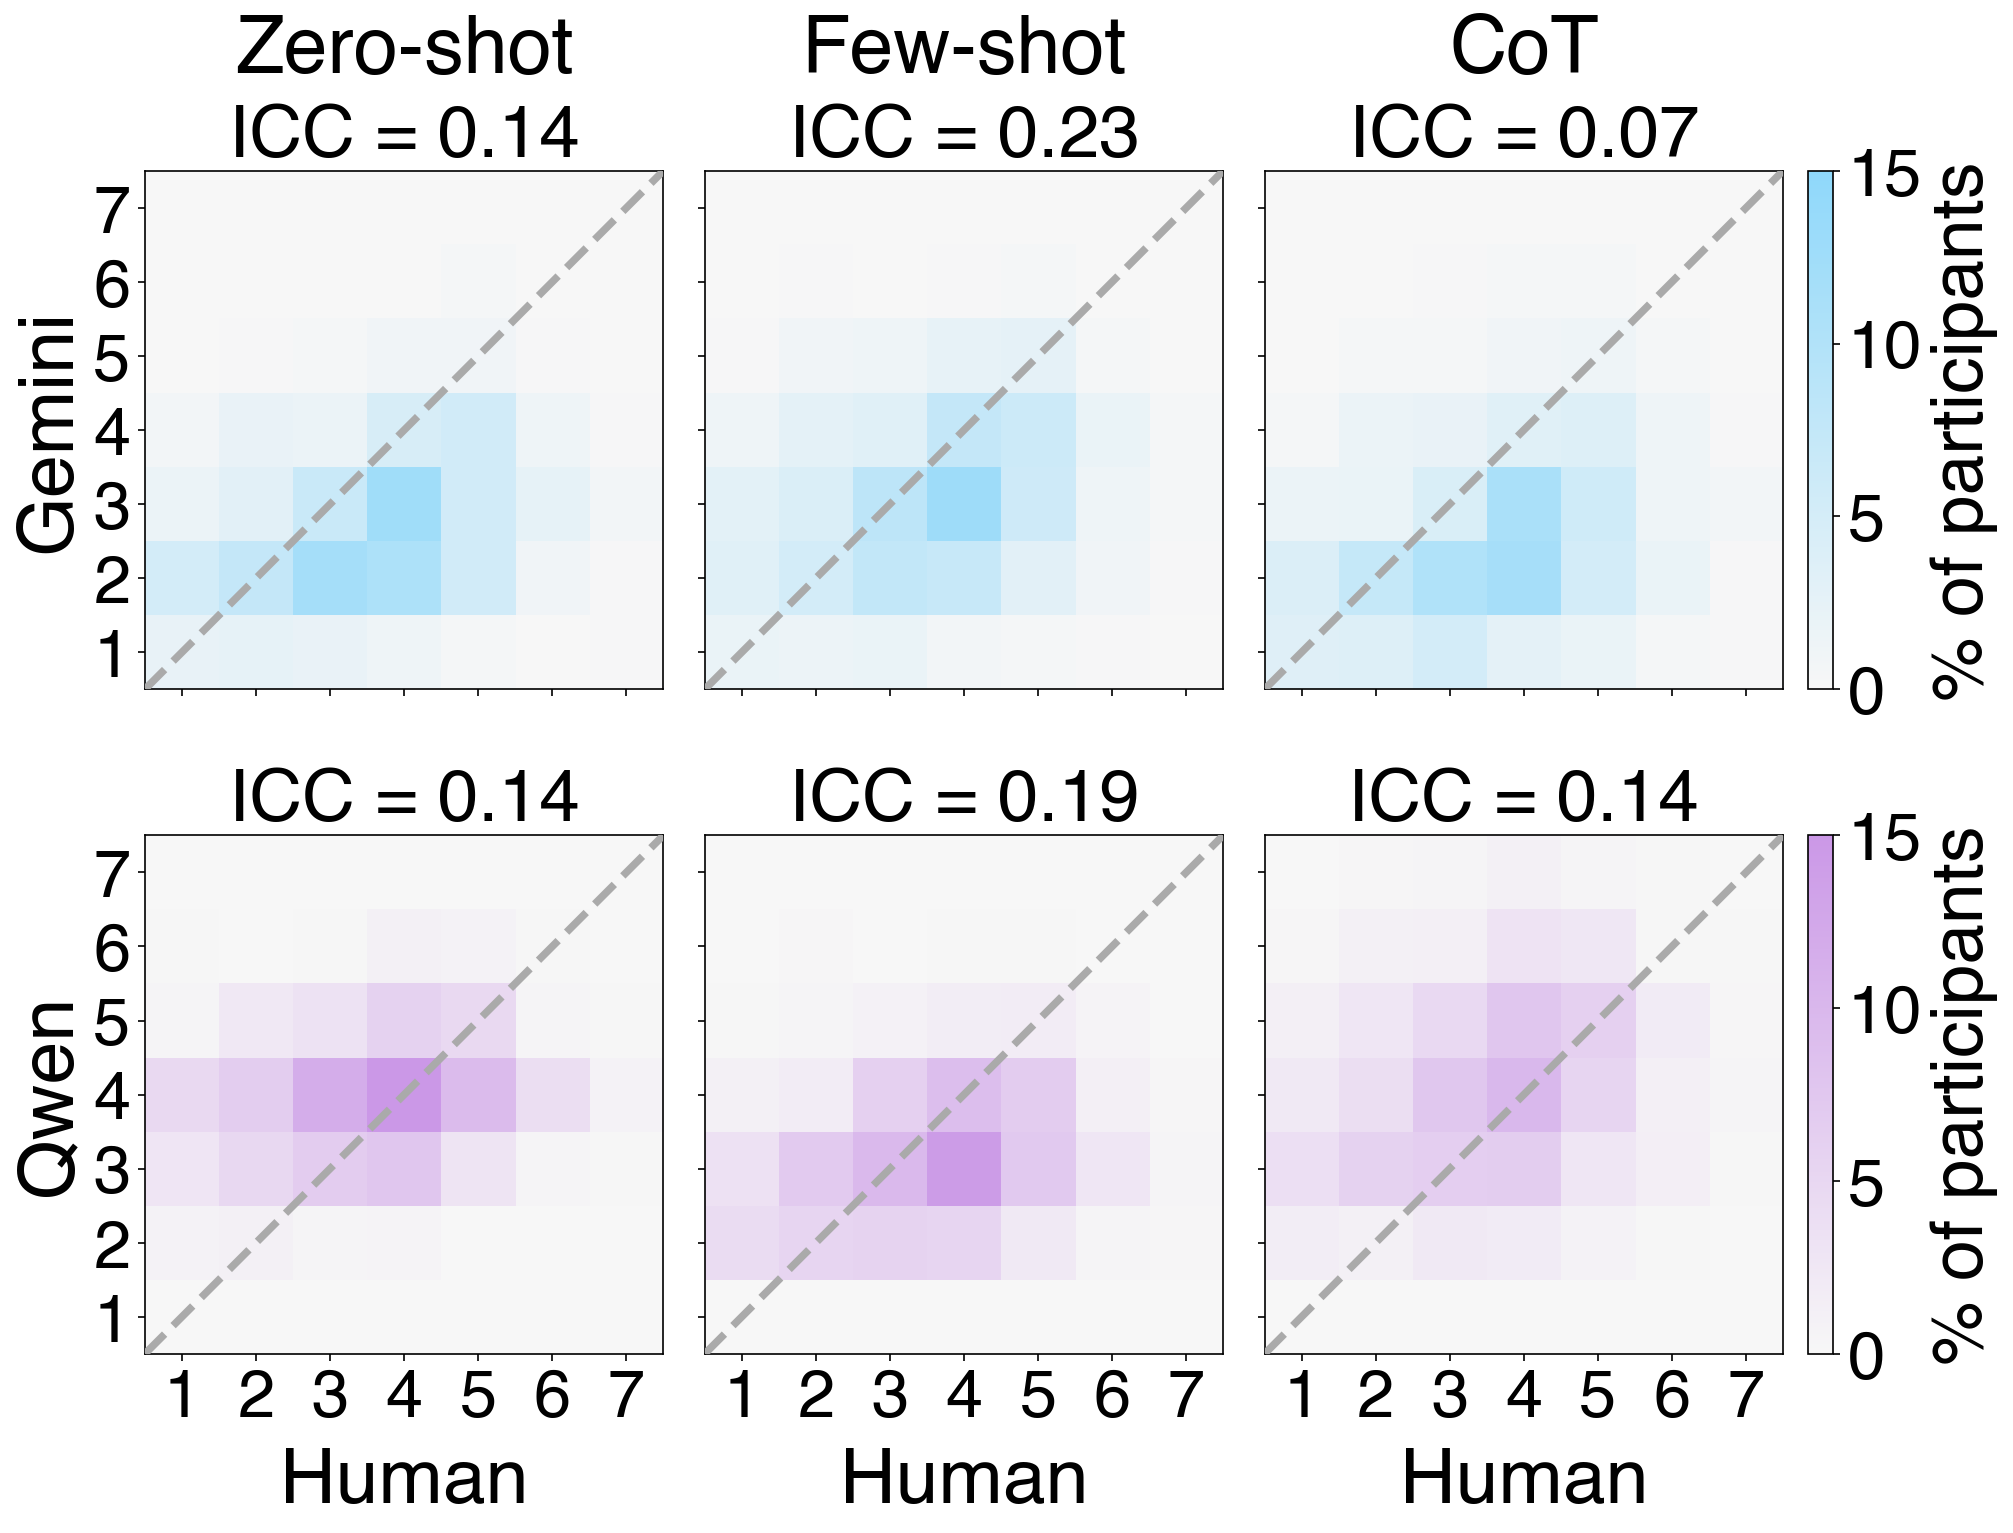

In [4]:
fig_2.generate(args, Path("_nb/fig_2.png"))
display(Image("_nb/fig_2.png"))

## Figure 3 — PMSV distributions across prompting methods

[fig3] → _nb/fig_3.png


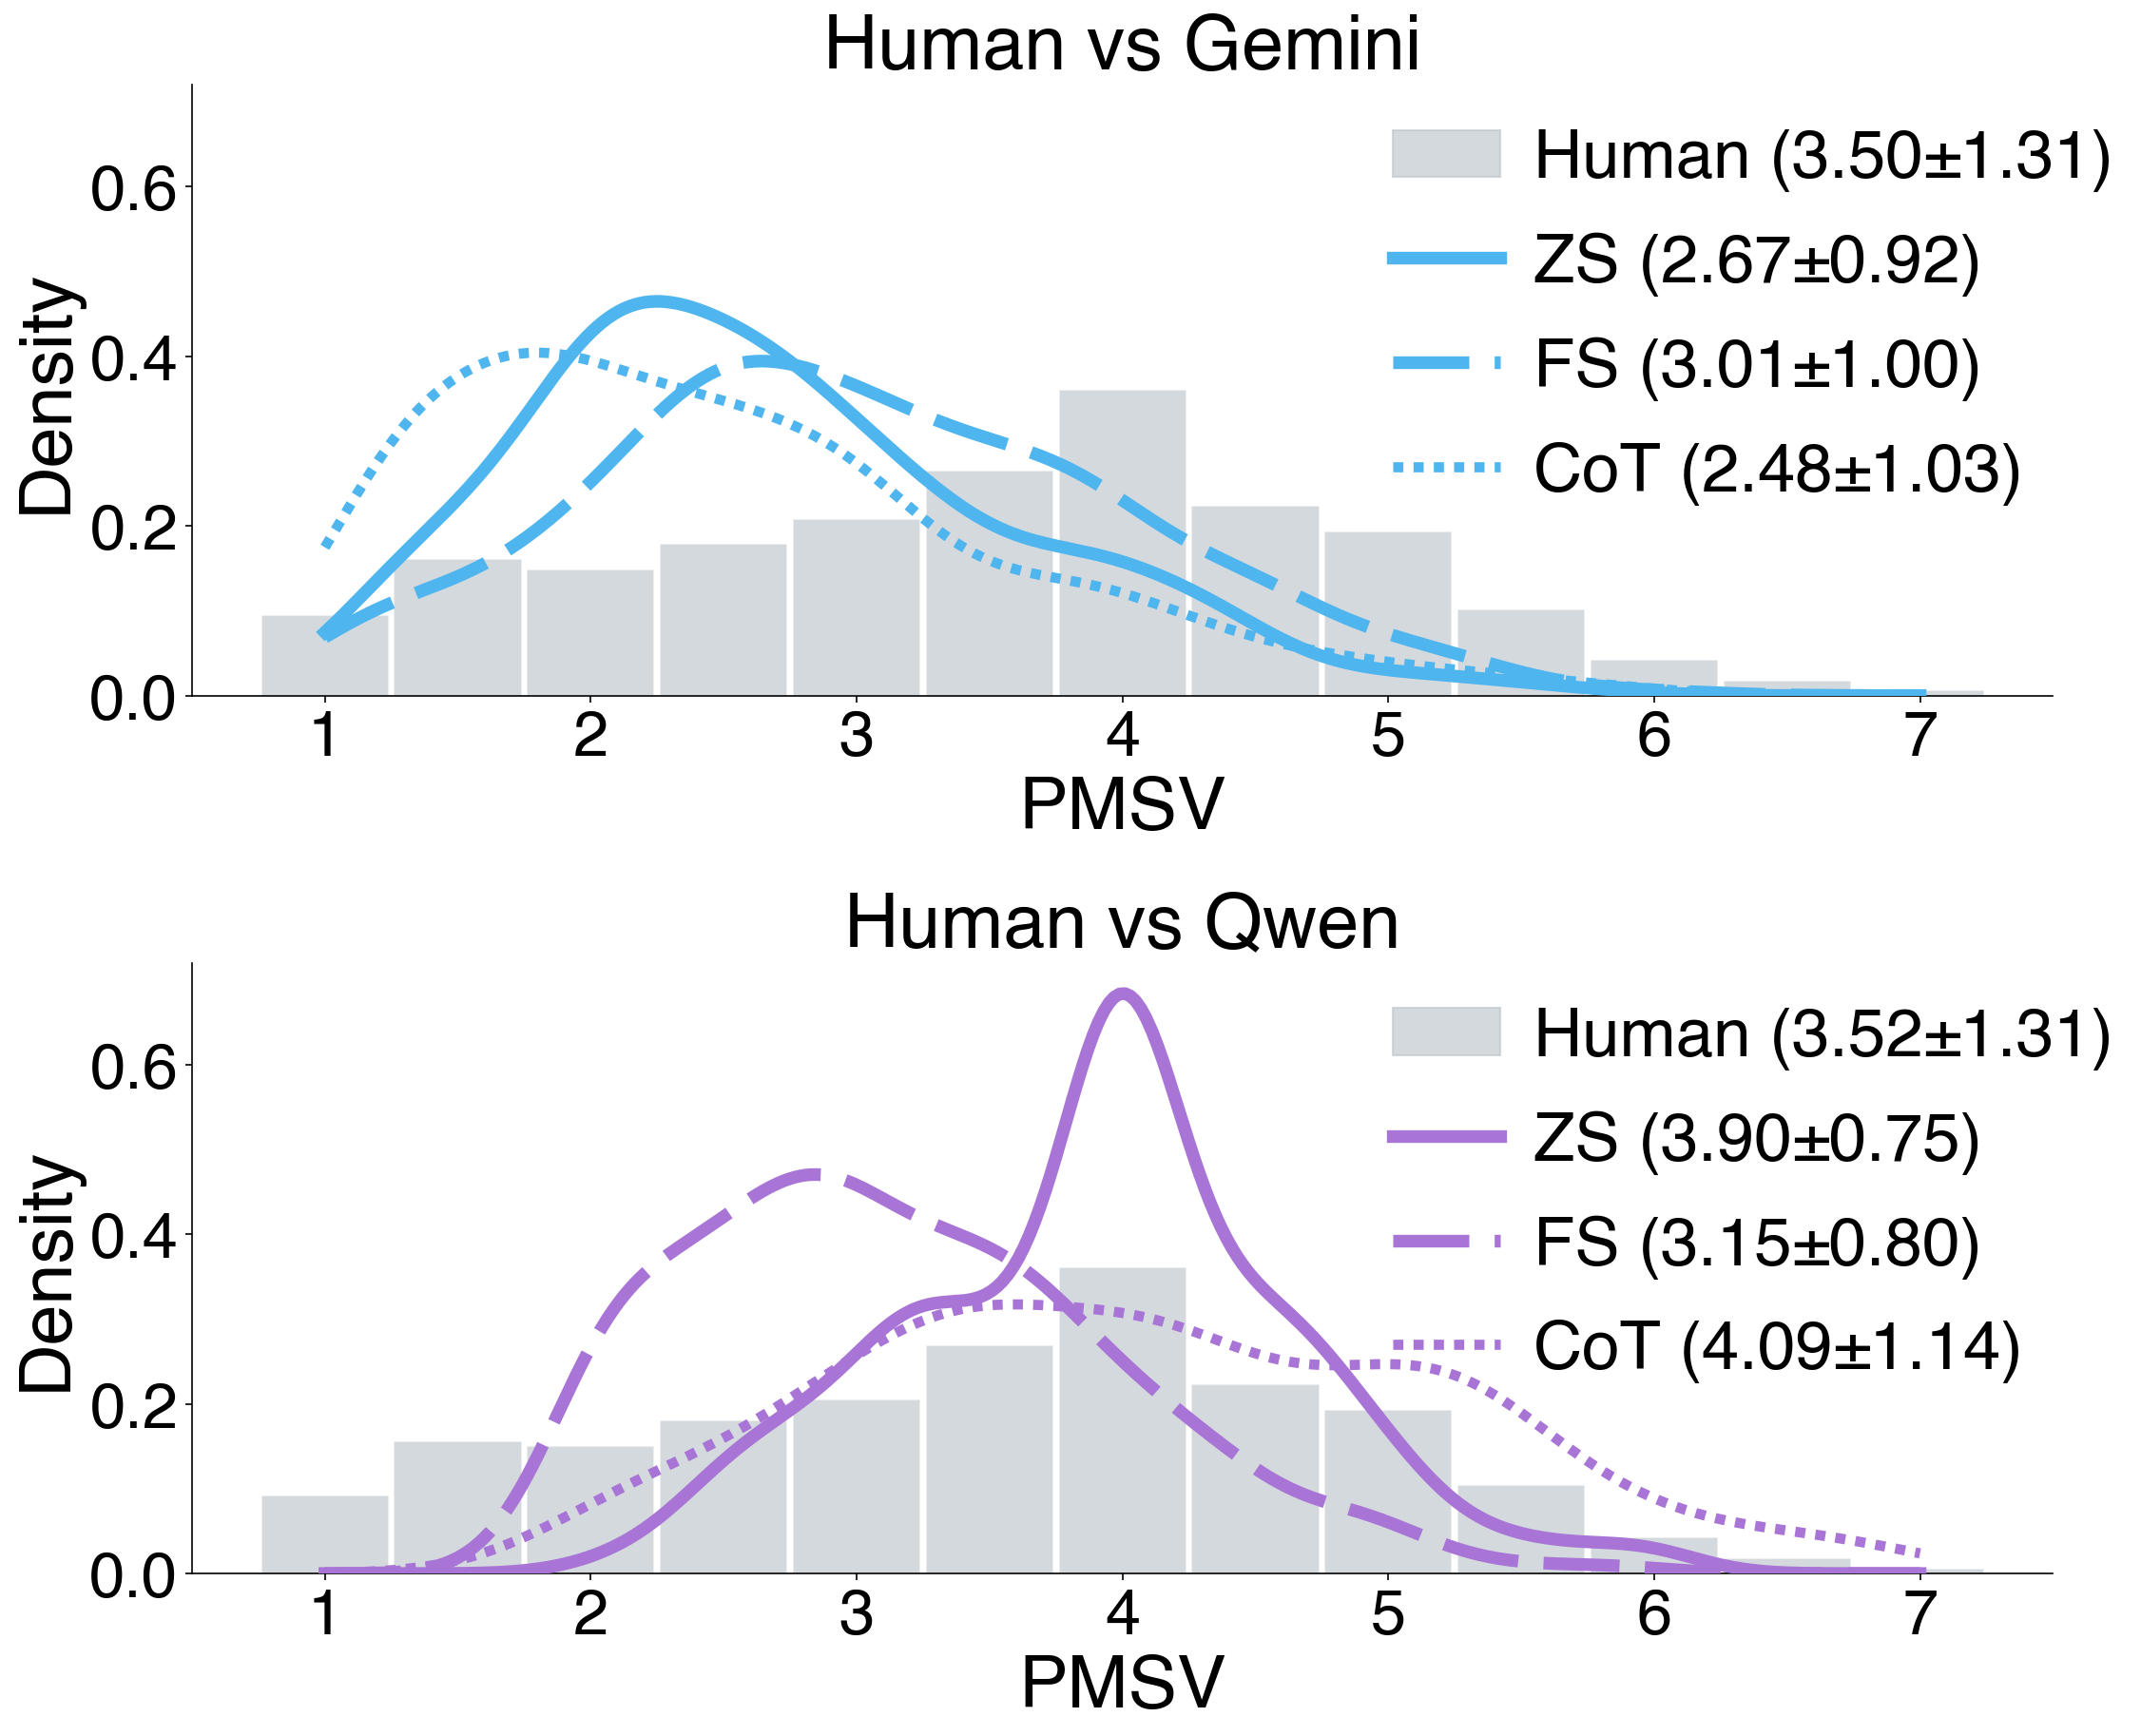

In [5]:
fig_3.generate(args, Path("_nb/fig_3.png"))
display(Image("_nb/fig_3.png"))

## Figure 4 — PMSV by age and gender (zero-shot)

[fig4] → _nb/fig_4_age.png  [interaction Gemini p=0.0054, Qwen p=0.0017]
[fig4] → _nb/fig_4_gender.png  [interaction Gemini p=0.0041, Qwen p=0.0215]


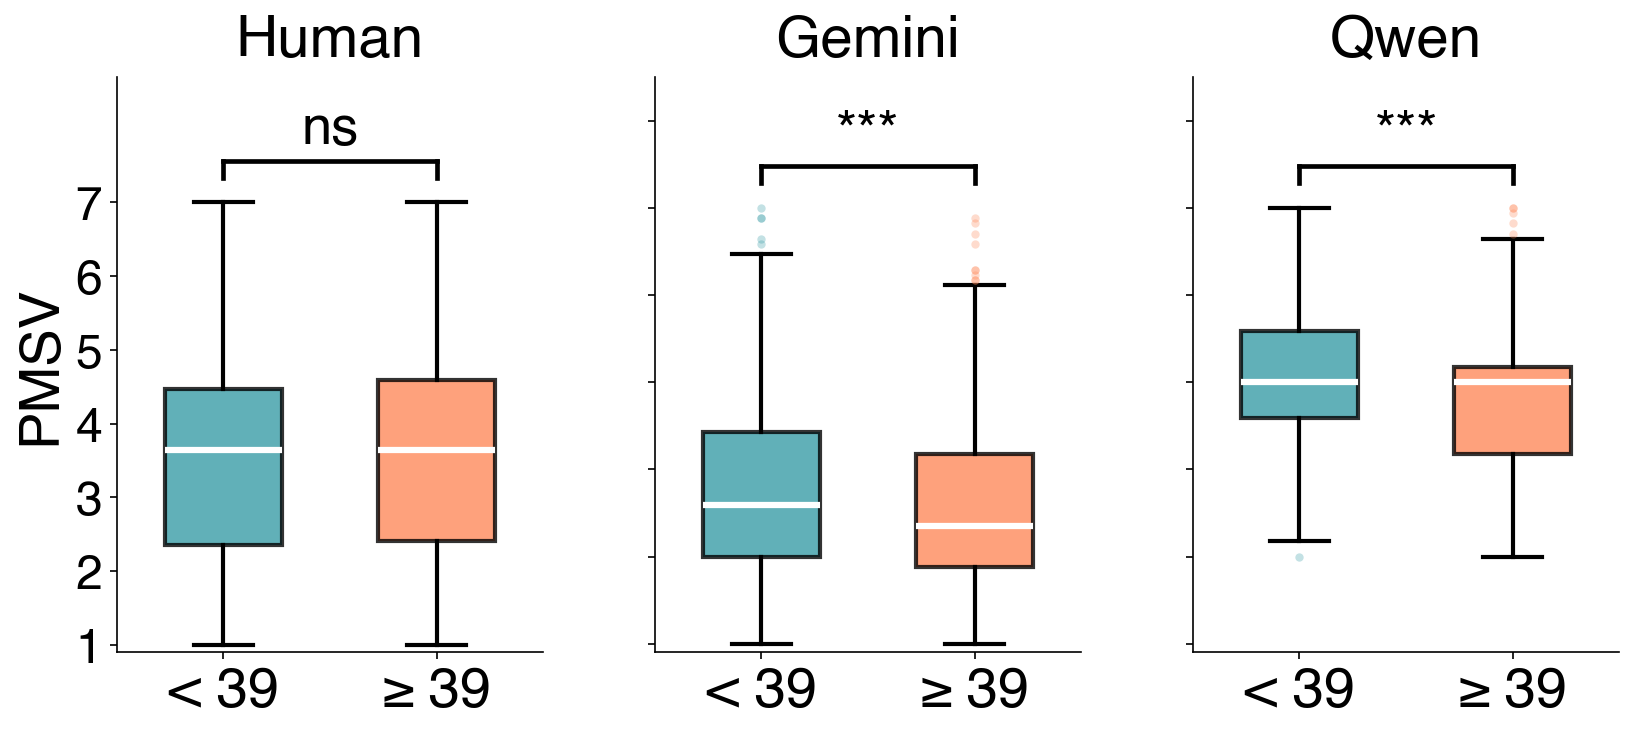

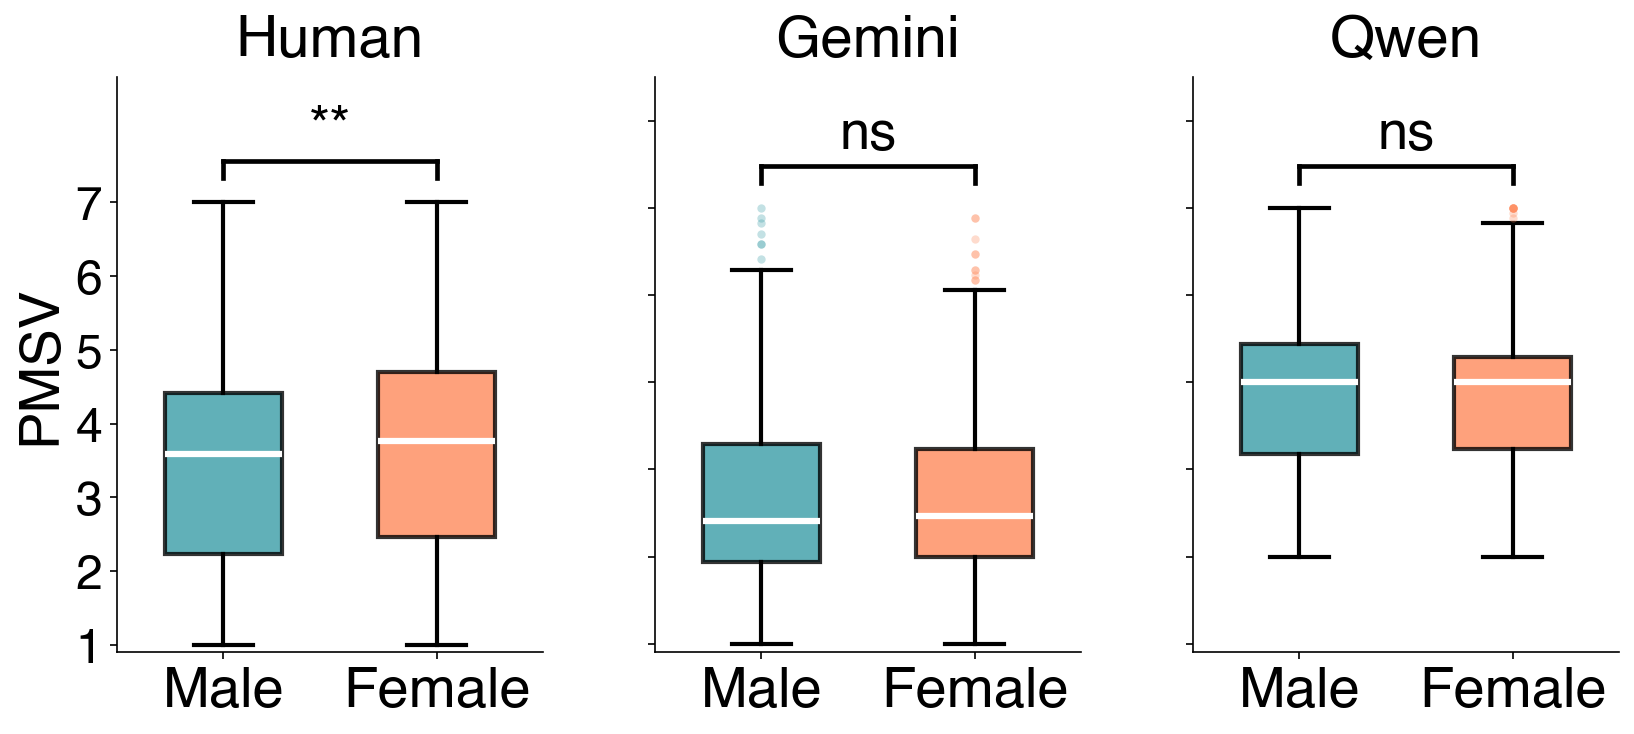

In [6]:
fig_4.generate(args, Path("_nb/fig_4_age.png"), Path("_nb/fig_4_gender.png"))
display(Image("_nb/fig_4_age.png"))
display(Image("_nb/fig_4_gender.png"))

## Figure 5 — Zero-shot vs Shuffled-profile (boxplot)

  → _nb/fig_5_gemini.png  [t-test p=0.0000 ***, n=673]
  → _nb/fig_5_qwen.png  [t-test p=0.3512 ns, n=647]


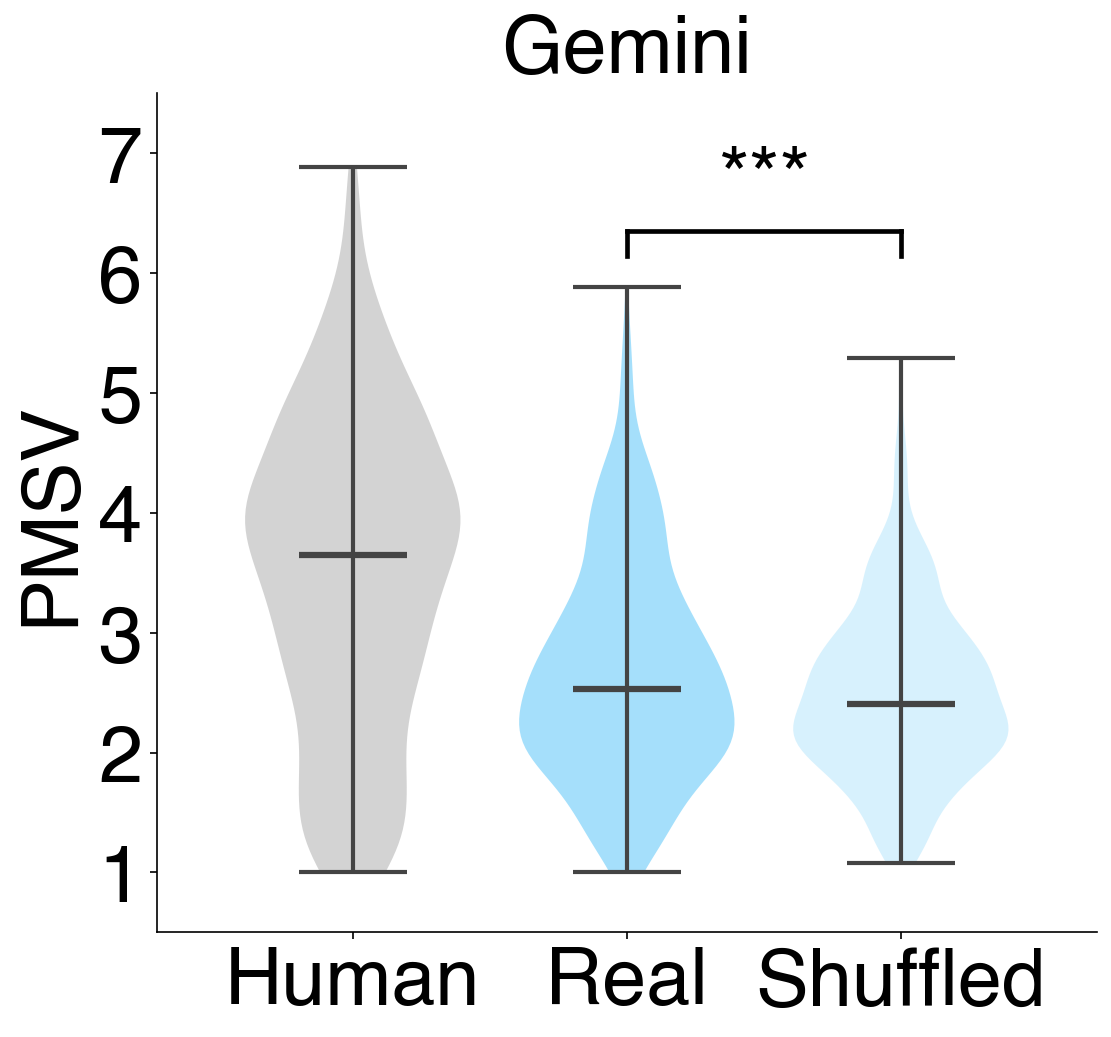

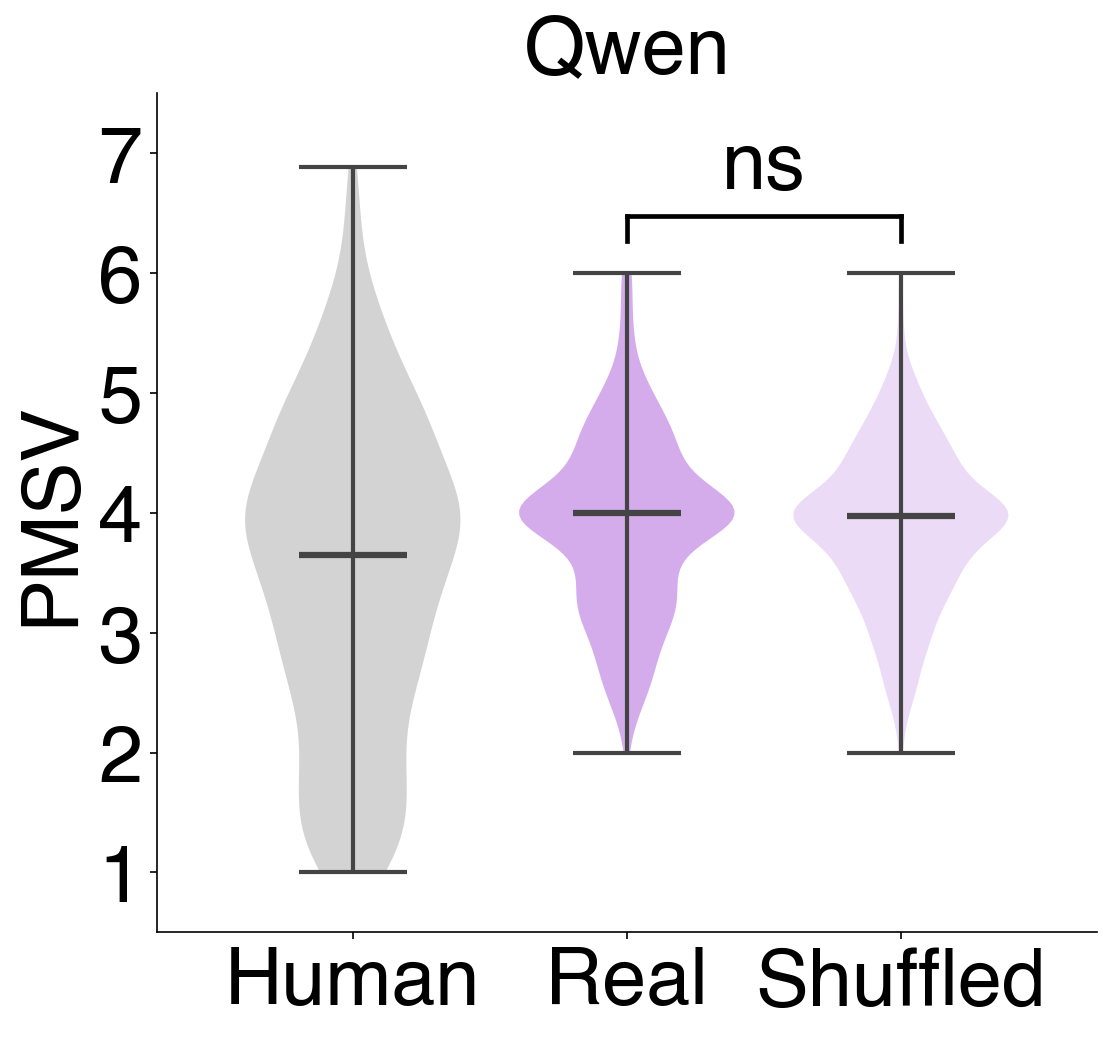

In [7]:
import fig_5

gemini_zs   = fig_5.load_ratings(Path('data/results/gemini_zero_shot.csv'))
gemini_shuf = fig_5.load_ensemble([
    Path('data/results/gemini_shuffled.csv'),
    Path('data/results/gemini_shuffled_run_2.csv'),
    Path('data/results/gemini_shuffled_run_3.csv'),
])
qwen_zs   = fig_5.load_ratings(Path('data/results/qwen_zero_shot.csv'))
qwen_shuf = fig_5.load_ensemble([
    Path('data/results/qwen_shuffled_run_1.csv'),
    Path('data/results/qwen_shuffled_run_2.csv'),
    Path('data/results/qwen_shuffled_run_3.csv'),
])
human_df = fig_5.load_human_df(Path('data/results/gemini_zero_shot.csv'))

fig_5.draw_boxplot('gemini', human_df, gemini_zs, gemini_shuf, Path('_nb/fig_5_gemini.png'))
fig_5.draw_boxplot('qwen',   human_df, qwen_zs,   qwen_shuf,   Path('_nb/fig_5_qwen.png'))

display(Image('_nb/fig_5_gemini.png'))
display(Image('_nb/fig_5_qwen.png'))